# Идентификация пород собак
Этот ноутбук содержит базовое решение для соревнования Dog Breed Identification.

In [3]:
import os
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split

## 1. Загрузка и настройка датасета

In [4]:
from kagglehub.auth import get_username

username = get_username()

if username is None:
    print("Вы не авторизованы в Kaggle. Запуск процесса авторизации...")
    kagglehub.login()
    raise RuntimeError("Пожалуйста, введите ваш API-токен Kaggle в интерактивном окне выше и запустите эту ячейку снова.")

print(f"Вы авторизованы как пользователь: {username}")

Вы авторизованы как пользователь: feytox


In [5]:
print("Загрузка датасета...")
path = kagglehub.competition_download('dog-breed-identification')

DATA_DIR = Path(path)
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
LABELS_CSV = DATA_DIR / "labels.csv"
SAMPLE_SUBMISSION_CSV = DATA_DIR / "sample_submission.csv"

Загрузка датасета...


## 2. Разведочный анализ данных (EDA)
Анализ распределения классов и проверка размеров изображений.

Размер датасета: (10222, 2)
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever
Минимум изображений на породу: 66
Максимум изображений на породу: 126


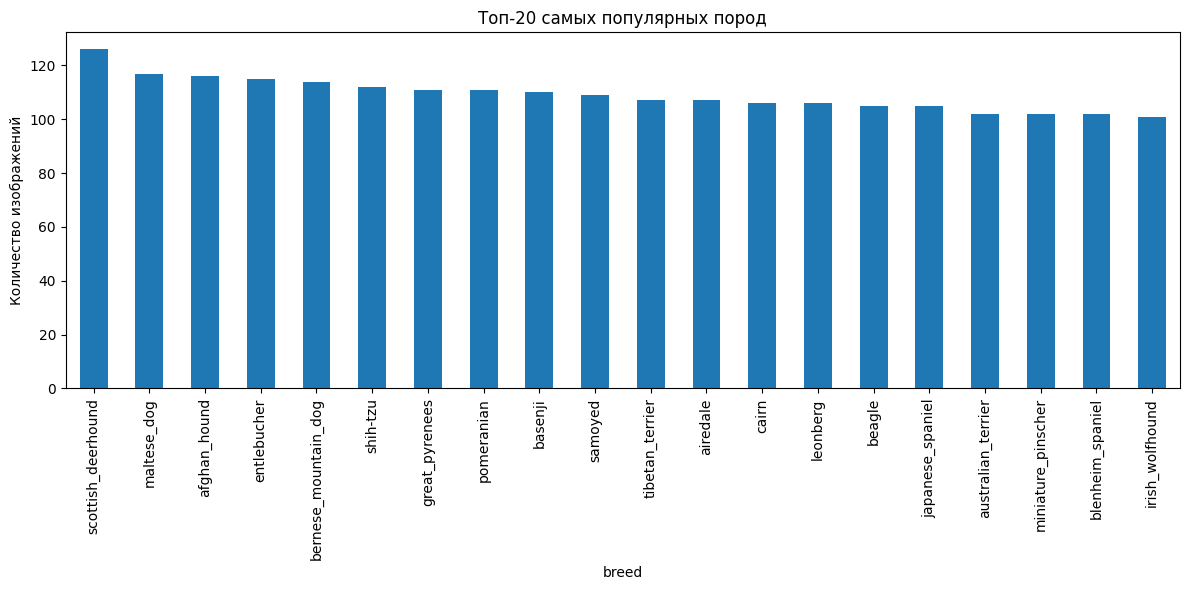

Пример изображения: 000bec180eb18c7604dcecc8fe0dba07.jpg, размер: (500, 375), каналы: RGB


In [6]:
df = pd.read_csv(LABELS_CSV)
print(f"Размер датасета: {df.shape}")
print(df.head())

counts = df["breed"].value_counts()
print(f"Минимум изображений на породу: {counts.min()}")
print(f"Максимум изображений на породу: {counts.max()}")

plt.figure(figsize=(12, 6))
counts.head(20).plot(kind="bar")
plt.title("Топ-20 самых популярных пород")
plt.ylabel("Количество изображений")
plt.tight_layout()
plt.show()

img_id = df.iloc[0]["id"]
img_path = TRAIN_DIR / f"{img_id}.jpg"
img = Image.open(img_path)
print(f"Пример изображения: {img_id}.jpg, размер: {img.size}, каналы: {img.mode}")

## 3. Разделение выборки
Разделение данных на обучающую и валидационную выборки с использованием стратификации для сохранения соотношения классов.

In [7]:
breeds = sorted(df["breed"].unique())
breed_to_idx = {b: i for i, b in enumerate(breeds)}
idx_to_breed = {i: b for i, b in enumerate(breeds)}
df["label"] = df["breed"].map(breed_to_idx)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print(f"Размер обучающей выборки: {train_df.shape[0]}")
print(f"Размер валидационной выборки: {val_df.shape[0]}")

Размер обучающей выборки: 8177
Размер валидационной выборки: 2045


## 4. Класс датасета и загрузчики данных
Определение класса `DogDataset` для загрузки изображений и применение аугментаций для обучения.

In [8]:
class DogDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.ids = df["id"].values
        self.labels = df["label"].values if "label" in df.columns else None

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_name = f"{self.ids[idx]}.jpg"
        img_path = self.img_dir / img_name
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.labels is not None:
            return image, self.labels[idx]
        return image, self.ids[idx]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = DogDataset(train_df, TRAIN_DIR, transform=train_transforms)
val_dataset = DogDataset(val_df, TRAIN_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

## 5. Инициализация предобученной модели ResNet-34
Загрузка ResNet-34 с весами ImageNet и изменение финального полносвязного слоя для классификации 120 пород собак.

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 120)
model = model.to(device)

print(f"Модель загружена и перемещена на: {device}")

Модель загружена и перемещена на: cuda


## 6. Функция потерь и оптимизатор
Настройка функции потерь CrossEntropyLoss, оптимизатора AdamW и планировщика скорости обучения.

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

## 7. Цикл обучения и валидации
Обучение модели в течение 5 эпох и сохранение лучших весов на основе потерь на валидационной выборке.

In [11]:
best_loss = float("inf")
epochs = 5

for epoch in range(epochs):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)
        
    scheduler.step()
    
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    
    model.eval()
    
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()
            val_total += labels.size(0)
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    print(f"Эпоха {epoch+1}/{epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("Сохранена лучшая модель.")

Эпоха 1/5
Train Loss: 2.4314 | Train Acc: 0.4937
Val Loss: 1.3101 | Val Acc: 0.6831
Сохранена лучшая модель.
Эпоха 2/5
Train Loss: 1.0075 | Train Acc: 0.7621
Val Loss: 0.9704 | Val Acc: 0.7262
Сохранена лучшая модель.
Эпоха 3/5
Train Loss: 0.5837 | Train Acc: 0.8634
Val Loss: 0.8094 | Val Acc: 0.7643
Сохранена лучшая модель.
Эпоха 4/5
Train Loss: 0.3538 | Train Acc: 0.9227
Val Loss: 0.7275 | Val Acc: 0.7834
Сохранена лучшая модель.
Эпоха 5/5
Train Loss: 0.2398 | Train Acc: 0.9582
Val Loss: 0.6983 | Val Acc: 0.8005
Сохранена лучшая модель.


## 8. Инференс на тестовой выборке и генерация сабмишна
Загрузка лучших сохраненных весов модели, выполнение инференса на тестовых данных, применение Softmax для расчета вероятностей и сохранение submission.csv.

In [12]:
test_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)
test_dataset = DogDataset(test_df, TEST_DIR, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

preds_list = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        
        preds_list.append(probs.cpu().numpy())

preds_array = np.vstack(preds_list)

submission = pd.DataFrame(preds_array, columns=breeds)
submission.insert(0, "id", test_df["id"].values)
submission.to_csv("submission.csv", index=False)

print("Файл submission.csv успешно сохранен.")

Файл submission.csv успешно сохранен.


## 9. Проверка файла сабмишна
Проверка размерности, отсутствия пустых значений и суммы вероятностей.

In [13]:
sub = pd.read_csv("submission.csv")
print(f"Формат сабмишна: {sub.shape}")
print(sub.head())
print(f"Есть ли пропущенные значения: {sub.isnull().any().any()}")

row_sums = sub.iloc[:, 1:].sum(axis=1)
print(f"Минимальная сумма строки: {row_sums.min():.4f}")
print(f"Максимальная сумма строки: {row_sums.max():.4f}")

Формат сабмишна: (10357, 121)
                                 id  affenpinscher  afghan_hound  \
0  000621fb3cbb32d8935728e48679680e       0.000173      0.000218   
1  00102ee9d8eb90812350685311fe5890       0.000028      0.000014   
2  0012a730dfa437f5f3613fb75efcd4ce       0.000171      0.002813   
3  001510bc8570bbeee98c8d80c8a95ec1       0.006363      0.008410   
4  001a5f3114548acdefa3d4da05474c2e       0.045342      0.001936   

   african_hunting_dog  airedale  american_staffordshire_terrier  appenzeller  \
0             0.000115  0.000065                        0.000140     0.000047   
1             0.000021  0.000007                        0.000018     0.000056   
2             0.000291  0.000385                        0.000268     0.000205   
3             0.000236  0.000037                        0.000782     0.000156   
4             0.000406  0.000117                        0.000575     0.001054   

   australian_terrier   basenji    basset  ...  toy_poodle  toy_terrier  \